# Per-category evaluator vs baseline scatter plots (all evaluators)

Same experiment as `evaluate.ipynb` but using the full set of evaluator result files.
A point on the diagonal $y=x$ means the evaluator agreed exactly with the baseline (Claude Sonnet 4) for that story.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120

## Load baseline and all evaluator results

In [2]:
results_dir = Path("../dataset/results")
baseline_path = results_dir / "claude_sonnet(baseline).csv"

def pretty_name(stem: str) -> str:
    s = stem.replace("_result", "")
    s = s.replace("-InstructMode-General", " (General)")
    s = s.replace("-Instruct", "").replace("-it", "").replace("-2507", "")
    s = s.replace("-BF16", "")
    s = s.replace("nvidia-", "")
    return s

baseline_df = pd.read_csv(baseline_path)

evaluators = {}
for p in sorted(results_dir.glob("*_result.csv")):
    evaluators[pretty_name(p.stem)] = pd.read_csv(p)

print(f"Baseline rows: {len(baseline_df)}")
for name, df in evaluators.items():
    print(f"  {name}: {len(df)} rows")

Baseline rows: 767
  Qwen3-4B: 767 rows
  Qwen3.5-4B (General): 767 rows
  gemma-4-E2B: 767 rows
  gemma-4-E4B: 767 rows
  llama-3.2-3B: 767 rows
  nemotron-3-nano-4B: 767 rows


In [3]:
POSITIVE_CATEGORIES = [
    "Adherence to Instructions",
    "Believable Character Actions",
    "Nuanced Characters",
    "Consistent Voice / Tone of Writing",
    "Imagery and Descriptive Quality",
    "Elegant Prose",
    "Emotionally Engaging",
    "Emotionally Complex",
    "Coherent",
    "Well-earned Lightness or Darkness",
    "Sentences Flow Naturally",
    "Overall Reader Engagement",
    "Overall Impression",
]

NEGATIVE_CATEGORIES = [
    "Meandering",
    "Weak Dialogue",
    "Tell-Don't-Show",
    "Unsurprising or Uncreative",
    "Amateurish",
    "Purple Prose",
    "Overwrought",
    "Incongruent Ending Positivity",
    "Unearned Transformations",
]

all_categories = POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES

## Build long-format table of (baseline, evaluator) score pairs

In [4]:
keys = ["index", "model"]

pair_frames = []
for name, df in evaluators.items():
    m = df.merge(baseline_df, on=keys, suffixes=("_ev", "_ref"), validate="one_to_one")
    for cat in all_categories:
        col = f"{cat}_score"
        pair_frames.append(pd.DataFrame({
            "evaluator": name,
            "category": cat,
            "type": "positive" if cat in POSITIVE_CATEGORIES else "negative",
            "baseline": m[f"{col}_ref"].to_numpy(),
            "score": m[f"{col}_ev"].to_numpy(),
        }))

pairs = pd.concat(pair_frames, ignore_index=True)
pairs.head()

,evaluator,category,type,baseline,score
0,Qwen3-4B,Adherence to Instructions,positive,19.0,19.5
1,Qwen3-4B,Adherence to Instructions,positive,19.0,19.5
2,Qwen3-4B,Adherence to Instructions,positive,19.0,19.5
3,Qwen3-4B,Adherence to Instructions,positive,19.0,19.5
4,Qwen3-4B,Adherence to Instructions,positive,19.0,19.5


## Scatter plot grid

Each subplot is one rubric category. Each evaluator has its own color. The dashed grey line is $y=x$ (perfect agreement with baseline). A small jitter is applied so overlapping integer/half-integer scores remain visible.

In [5]:
evaluator_names = sorted(evaluators.keys())
palette = dict(zip(evaluator_names, sns.color_palette("tab10", n_colors=len(evaluator_names))))

def scatter_grid(categories, title, ncols=3, jitter=0.15):
    n = len(categories)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False)
    rng = np.random.default_rng(0)

    for ax, cat in zip(axes.ravel(), categories):
        sub = pairs[pairs["category"] == cat]
        for ev in evaluator_names:
            s = sub[sub["evaluator"] == ev]
            if s.empty:
                continue
            x = s["baseline"].to_numpy() + rng.uniform(-jitter, jitter, len(s))
            y = s["score"].to_numpy() + rng.uniform(-jitter, jitter, len(s))
            ax.scatter(x, y, s=10, alpha=0.45, color=palette[ev], label=ev, edgecolors="none")

        lo = float(min(sub["baseline"].min(), sub["score"].min()))
        hi = float(max(sub["baseline"].max(), sub["score"].max()))
        pad = 0.5
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="grey", lw=1, zorder=0)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(cat, fontsize=10)
        ax.set_xlabel("Baseline (Claude Sonnet 4)")
        ax.set_ylabel("Evaluator score")

    for ax in axes.ravel()[n:]:
        ax.set_visible(False)

    handles = [plt.Line2D([0], [0], marker="o", color="w",
                          markerfacecolor=palette[ev], markersize=7, label=ev)
               for ev in evaluator_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(evaluator_names), 6),
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.0)
    fig.tight_layout()
    plt.show()

### Positive categories (higher = better)

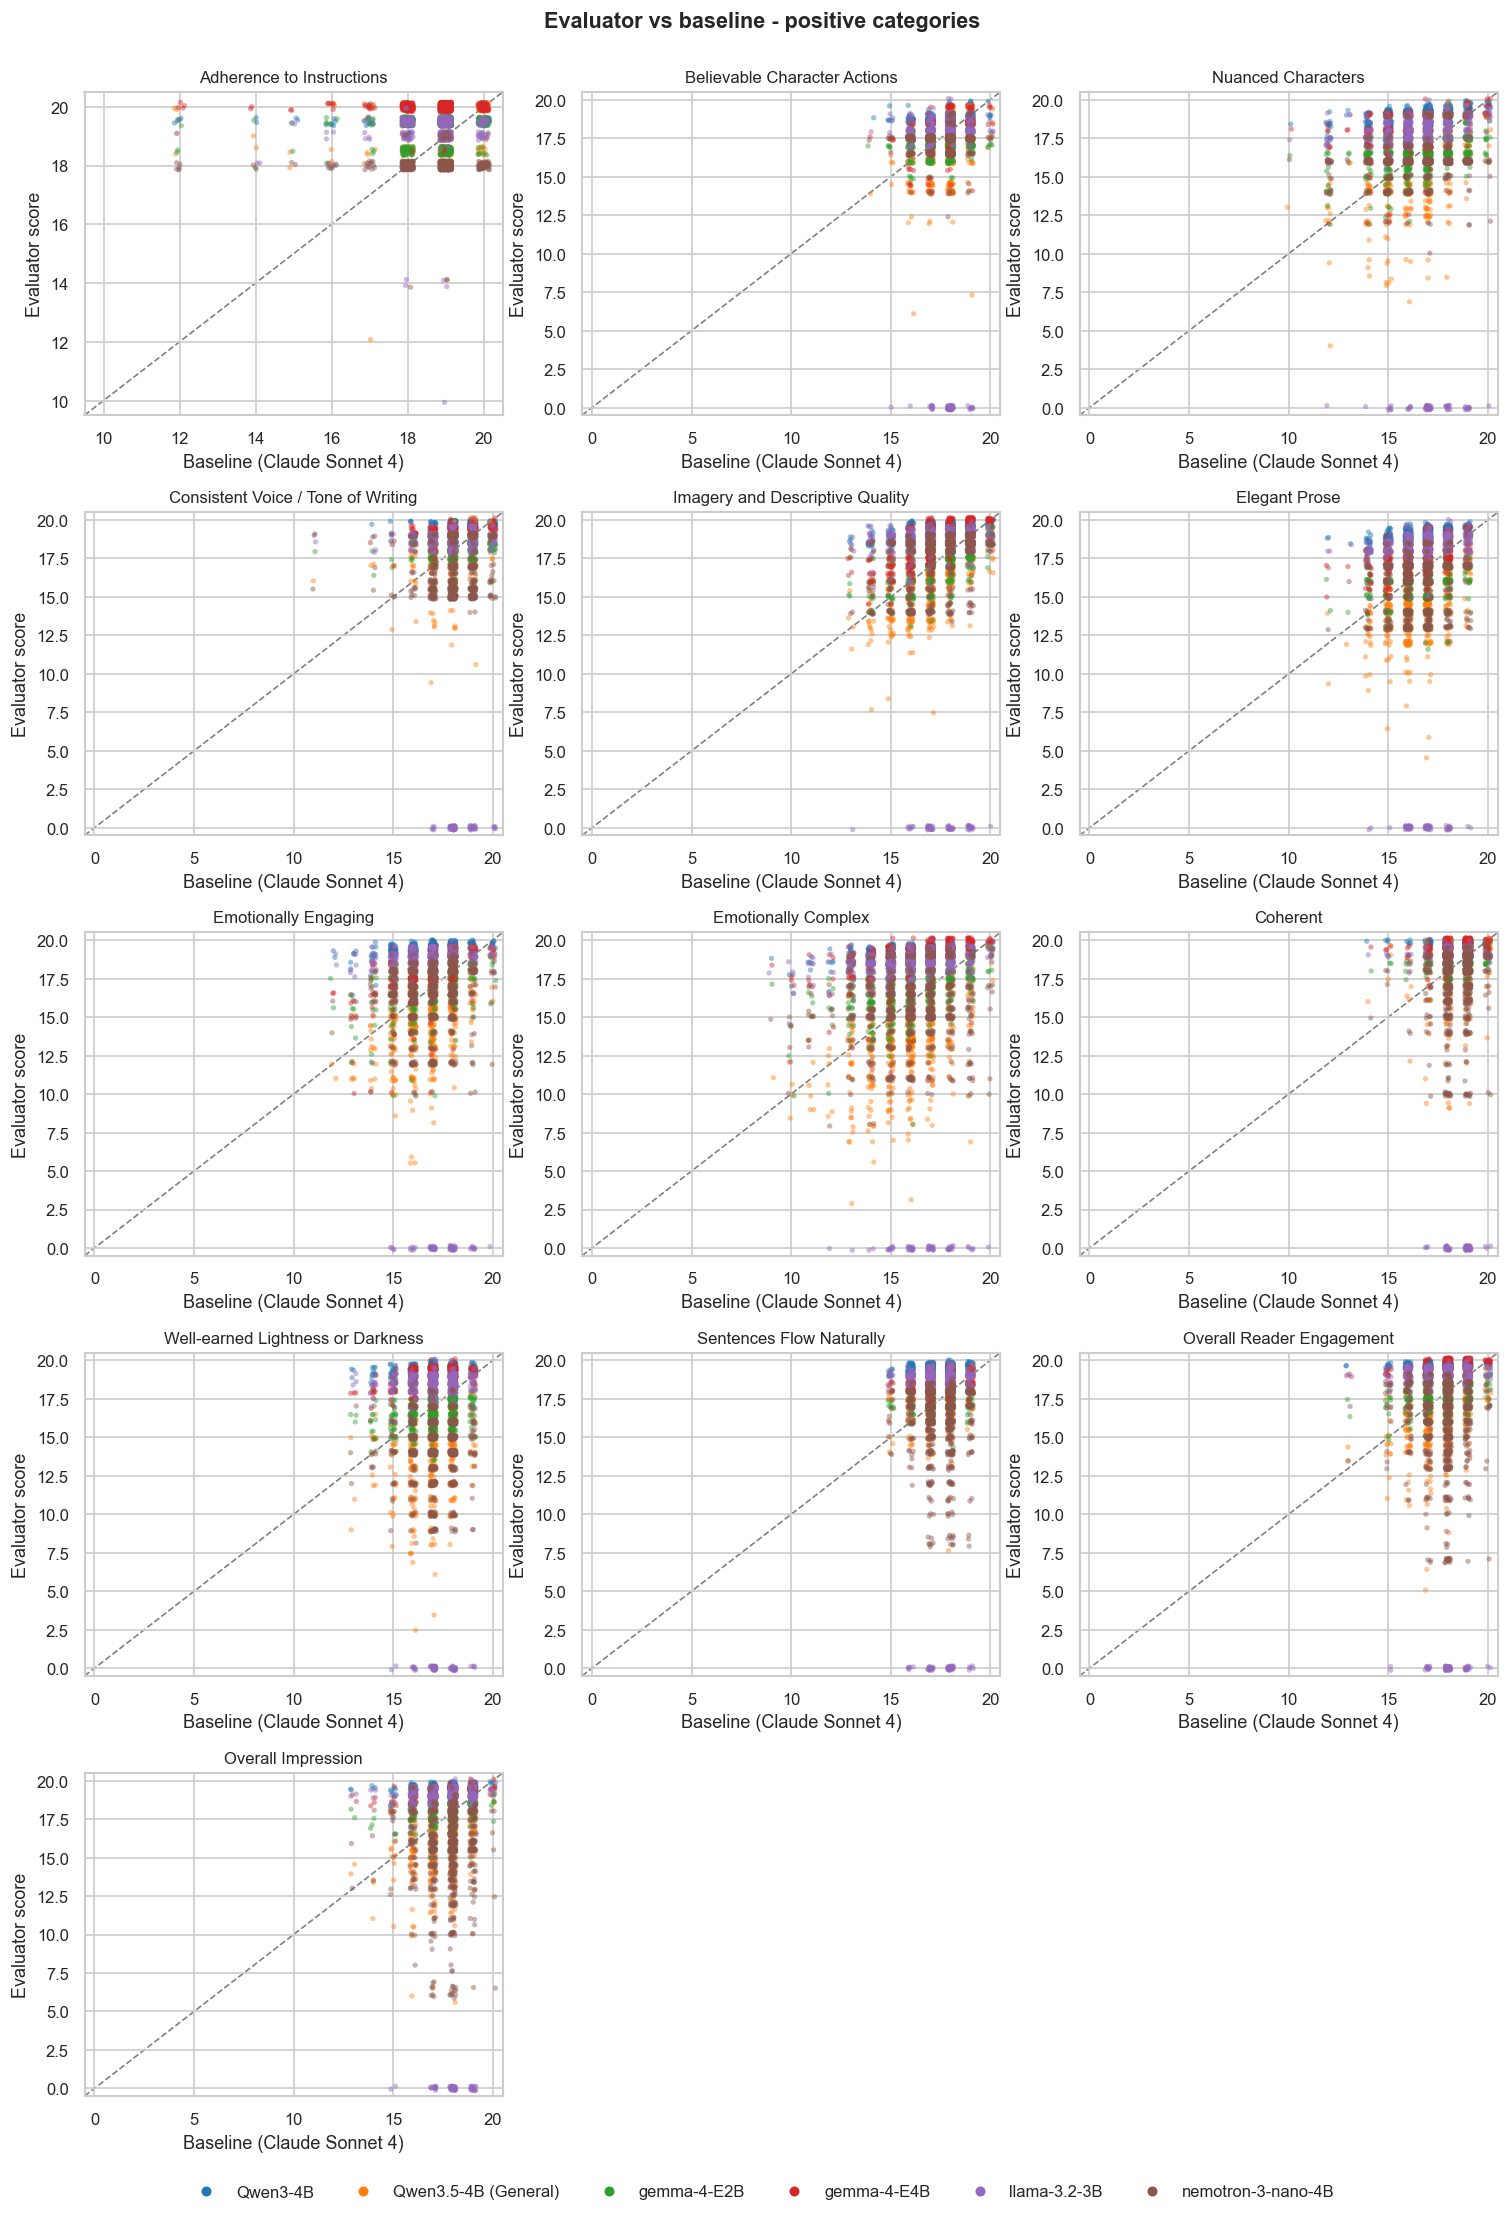

In [6]:
scatter_grid(POSITIVE_CATEGORIES, "Evaluator vs baseline - positive categories")

### Negative / penalty categories (lower = better)

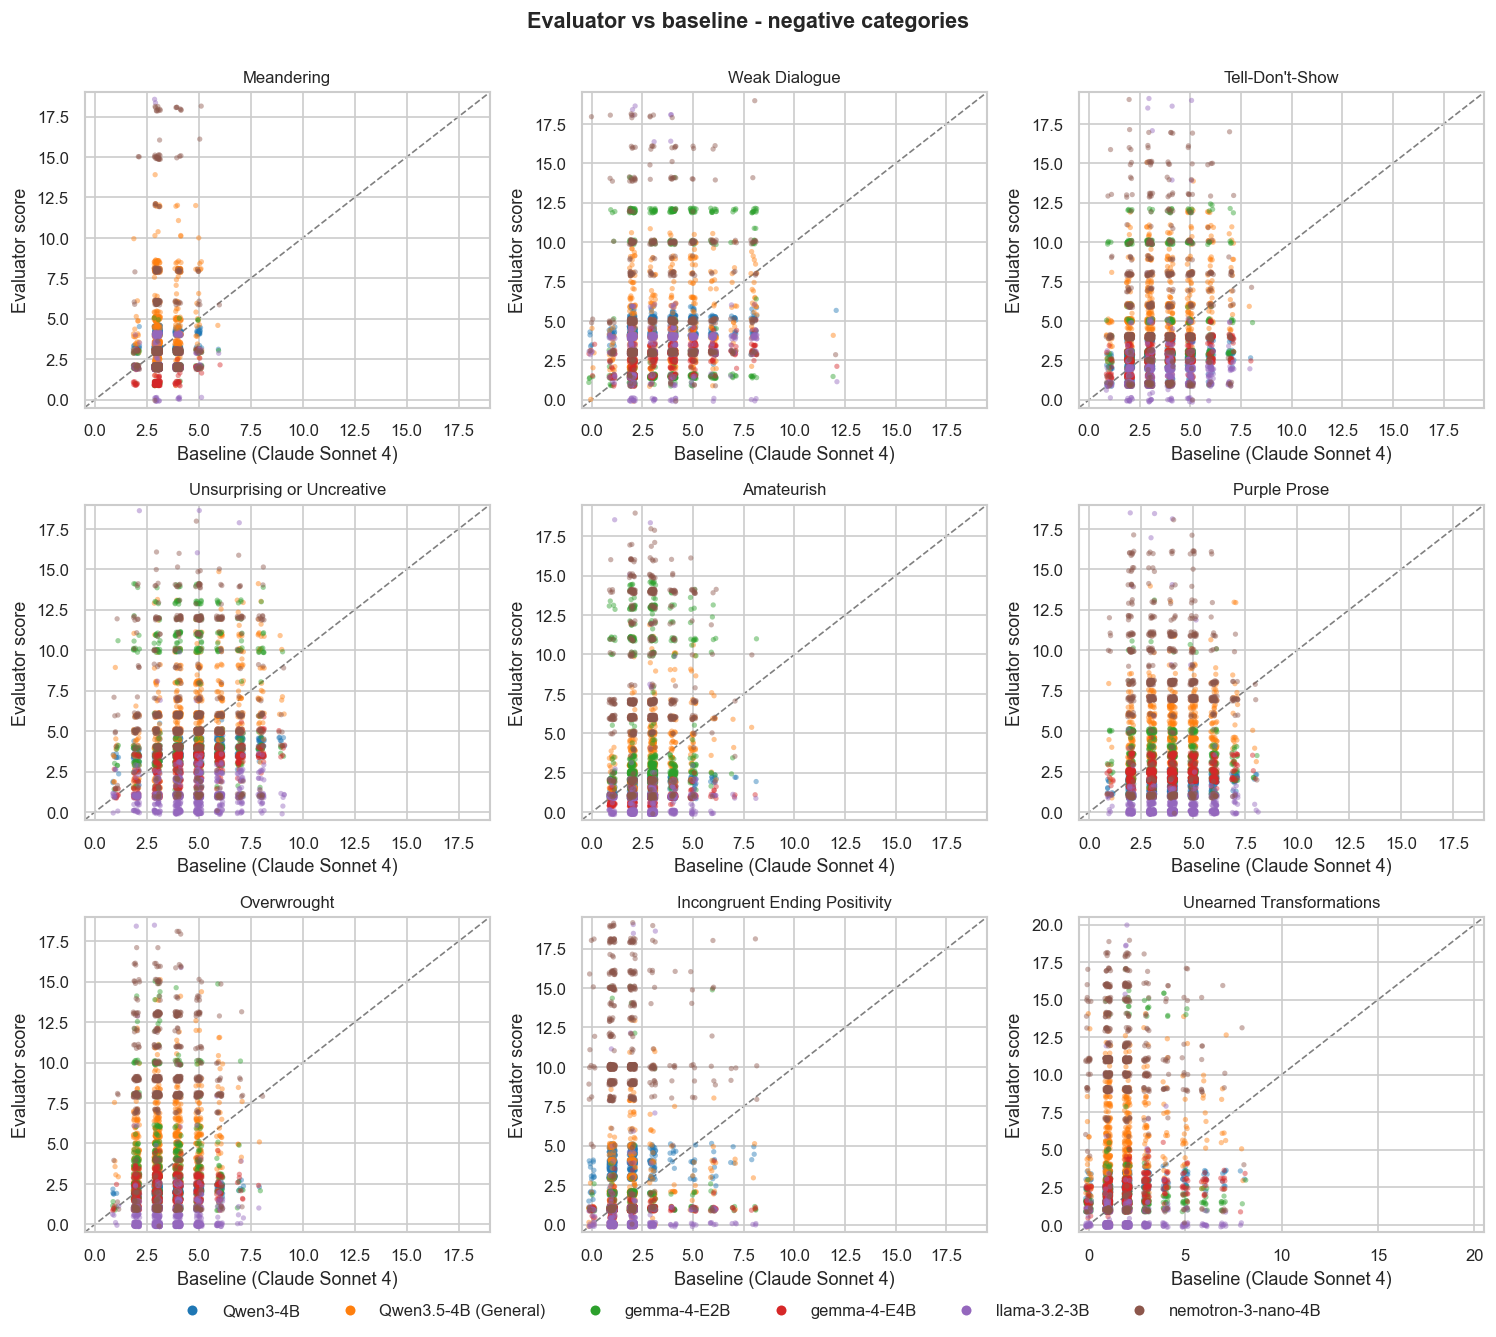

In [7]:
scatter_grid(NEGATIVE_CATEGORIES, "Evaluator vs baseline - negative categories")

## Per-category agreement summary

For each evaluator x category pair, compute Pearson correlation with the baseline and the mean signed bias. High correlation + near-zero bias means a tight scatter along the diagonal.

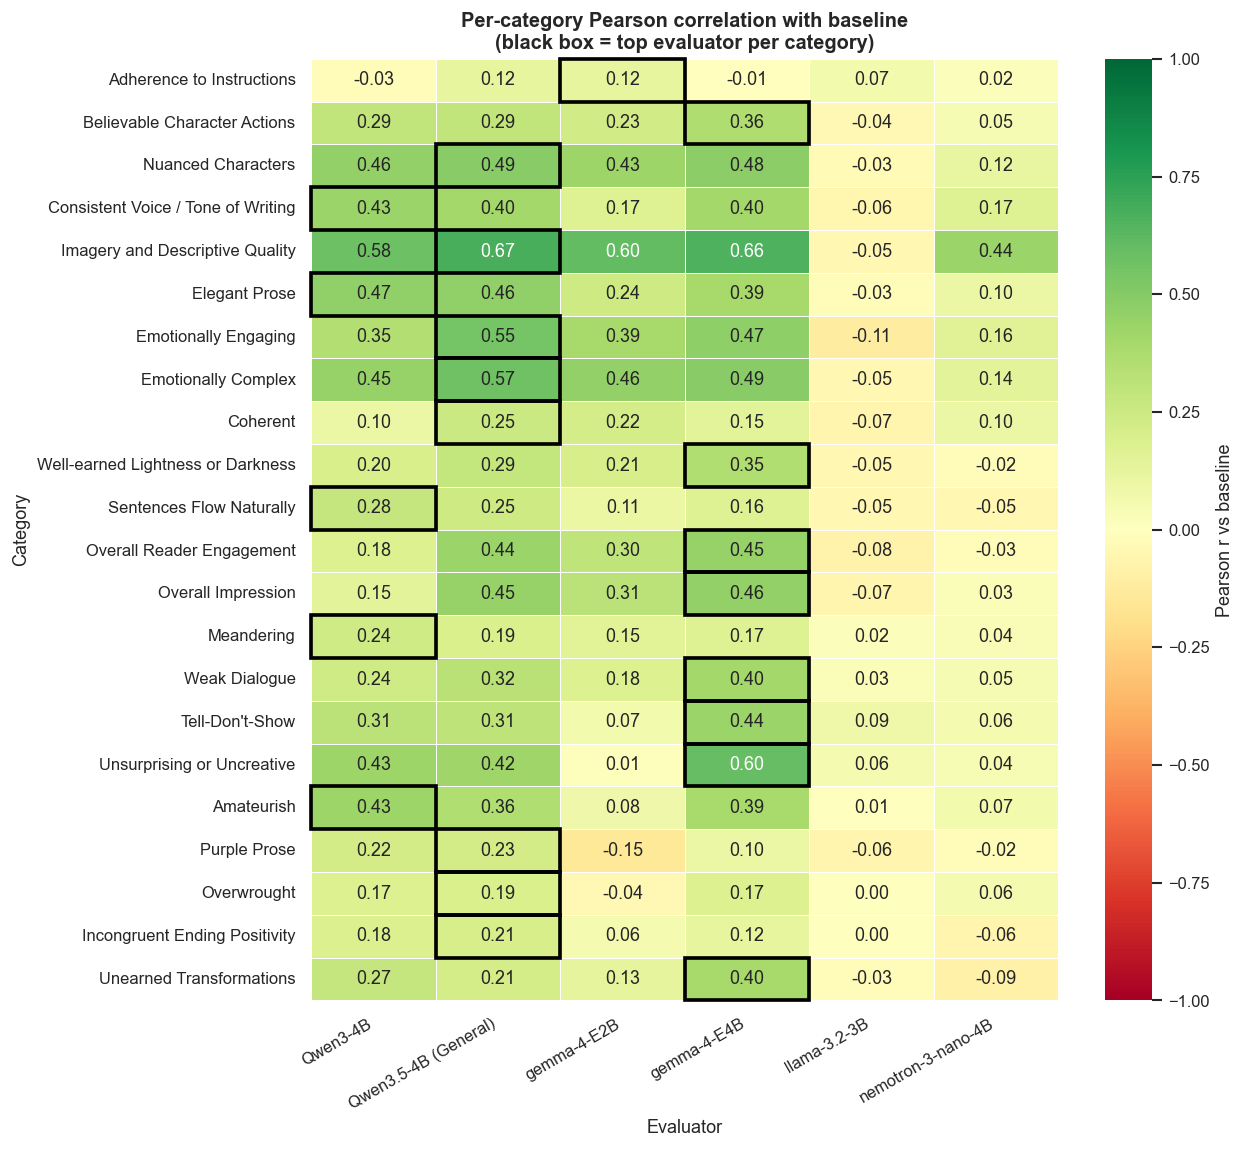

,evaluator,category,type,n,pearson_r,bias,mae
0,Qwen3-4B,Adherence to Instructions,positive,767,-0.025959,0.720860,0.786050
1,Qwen3.5-4B (General),Adherence to Instructions,positive,767,0.117399,0.554107,0.911343
2,gemma-4-E2B,Adherence to Instructions,positive,767,0.122681,0.408083,0.713168
3,gemma-4-E4B,Adherence to Instructions,positive,767,-0.005143,1.200782,1.203390
4,llama-3.2-3B,Adherence to Instructions,positive,767,0.066891,0.183181,0.691656
...,...,...,...,...,...,...,...
127,Qwen3.5-4B (General),Well-earned Lightness or Darkness,positive,767,0.285181,-2.816819,3.003259
128,gemma-4-E2B,Well-earned Lightness or Darkness,positive,767,0.209313,-0.624511,1.066493
129,gemma-4-E4B,Well-earned Lightness or Darkness,positive,767,0.355000,1.696219,1.705346
130,llama-3.2-3B,Well-earned Lightness or Darkness,positive,767,-0.048427,-0.306128,2.759061


In [8]:
def compute_agreement(pairs_df):
    rows = []
    for (ev, cat), g in pairs_df.groupby(["evaluator", "category"]):
        x = g["baseline"].to_numpy()
        y = g["score"].to_numpy()
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]
        if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
            r = np.nan
        else:
            r = float(np.corrcoef(x, y)[0, 1])
        diff = y - x
        rows.append({
            "evaluator": ev,
            "category": cat,
            "type": g["type"].iloc[0],
            "n": int(len(x)),
            "pearson_r": r,
            "bias": float(diff.mean()) if len(diff) else np.nan,
            "mae": float(np.abs(diff).mean()) if len(diff) else np.nan,
        })
    return pd.DataFrame(rows)


def plot_agreement_heatmap(pairs_df, title="Per-category Pearson correlation with baseline",
                           highlight_winner=True):
    agree_df = compute_agreement(pairs_df)
    pivot = (
        agree_df.pivot_table(index="category", columns="evaluator", values="pearson_r")
        .reindex(index=POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES, columns=evaluator_names)
    )

    plt.figure(figsize=(1.1 * len(evaluator_names) + 4, 0.35 * len(pivot) + 2))
    ax = sns.heatmap(pivot, cmap="RdYlGn", vmin=-1, vmax=1, center=0,
                     annot=True, fmt=".2f", linewidths=0.4, linecolor="white",
                     cbar_kws={"label": "Pearson r vs baseline"})

    if highlight_winner:
        max_cols = pivot.idxmax(axis=1)
        for row_idx, cat in enumerate(pivot.index):
            ev = max_cols.loc[cat]
            if pd.isna(ev):
                continue
            col_idx = pivot.columns.get_loc(ev)
            ax.add_patch(mpatches.Rectangle((col_idx, row_idx), 1, 1,
                                            fill=False, edgecolor="black",
                                            lw=2.2, clip_on=False))
        title = f"{title}\n(black box = top evaluator per category)"

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Evaluator")
    plt.ylabel("Category")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    return ax


agreement = compute_agreement(pairs)
plot_agreement_heatmap(pairs)
plt.show()

agreement.sort_values(["category", "evaluator"]).reset_index(drop=True)

## Stability check via square-root subsampling

Each figure is built from an independent random subsample of size $\sqrt{N}$ per evaluator-category group. Comparing heatmaps shows how much the per-category Pearson agreement fluctuates under small samples.

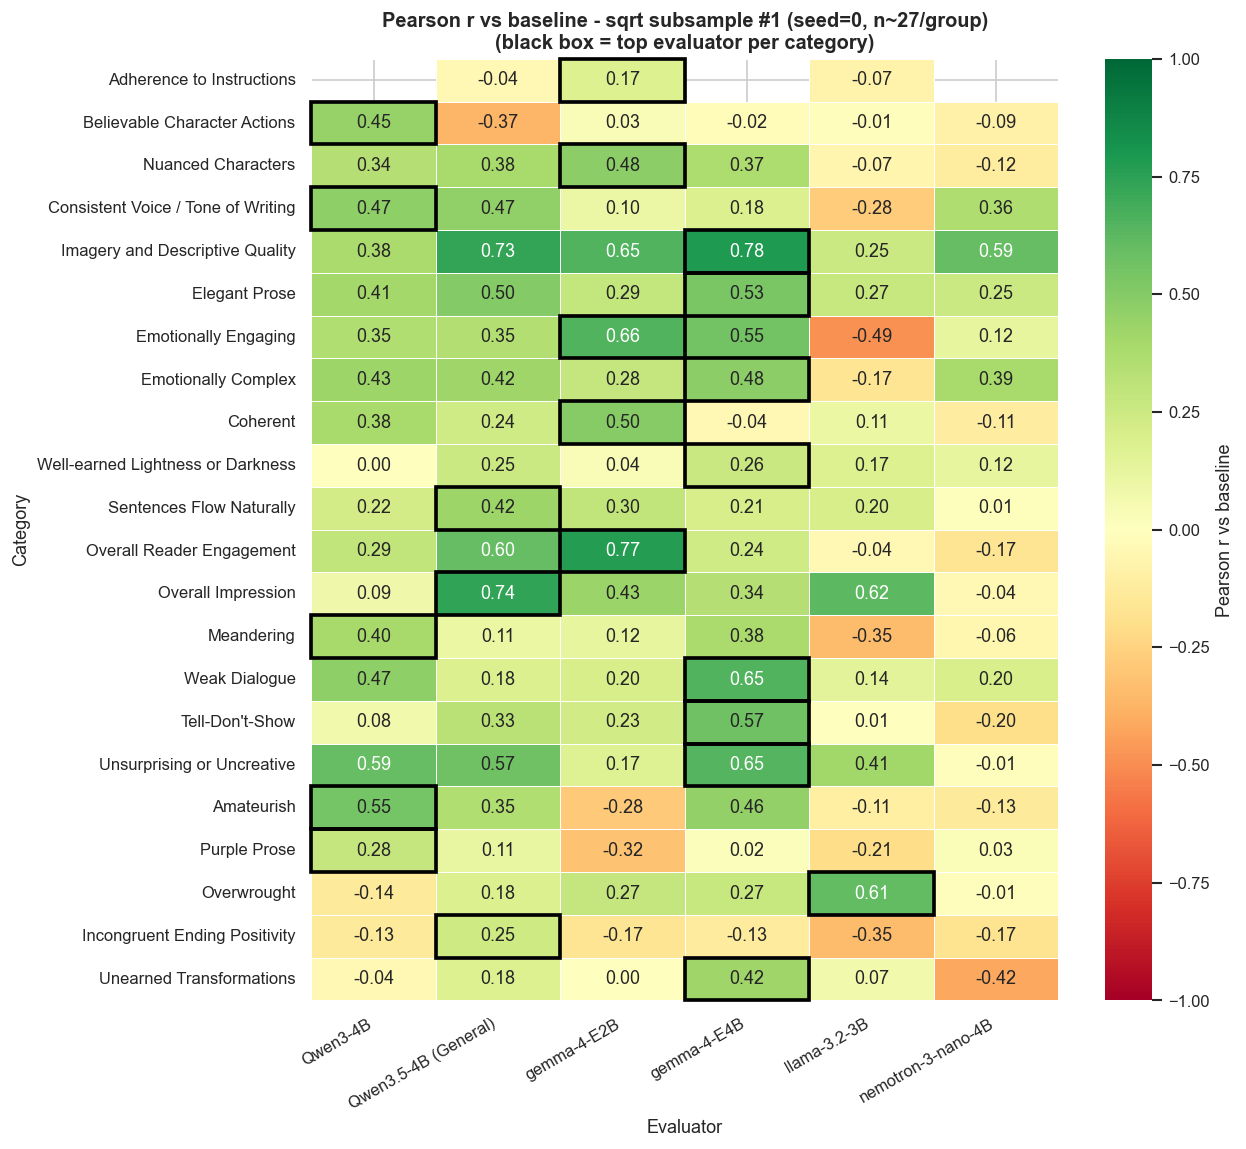

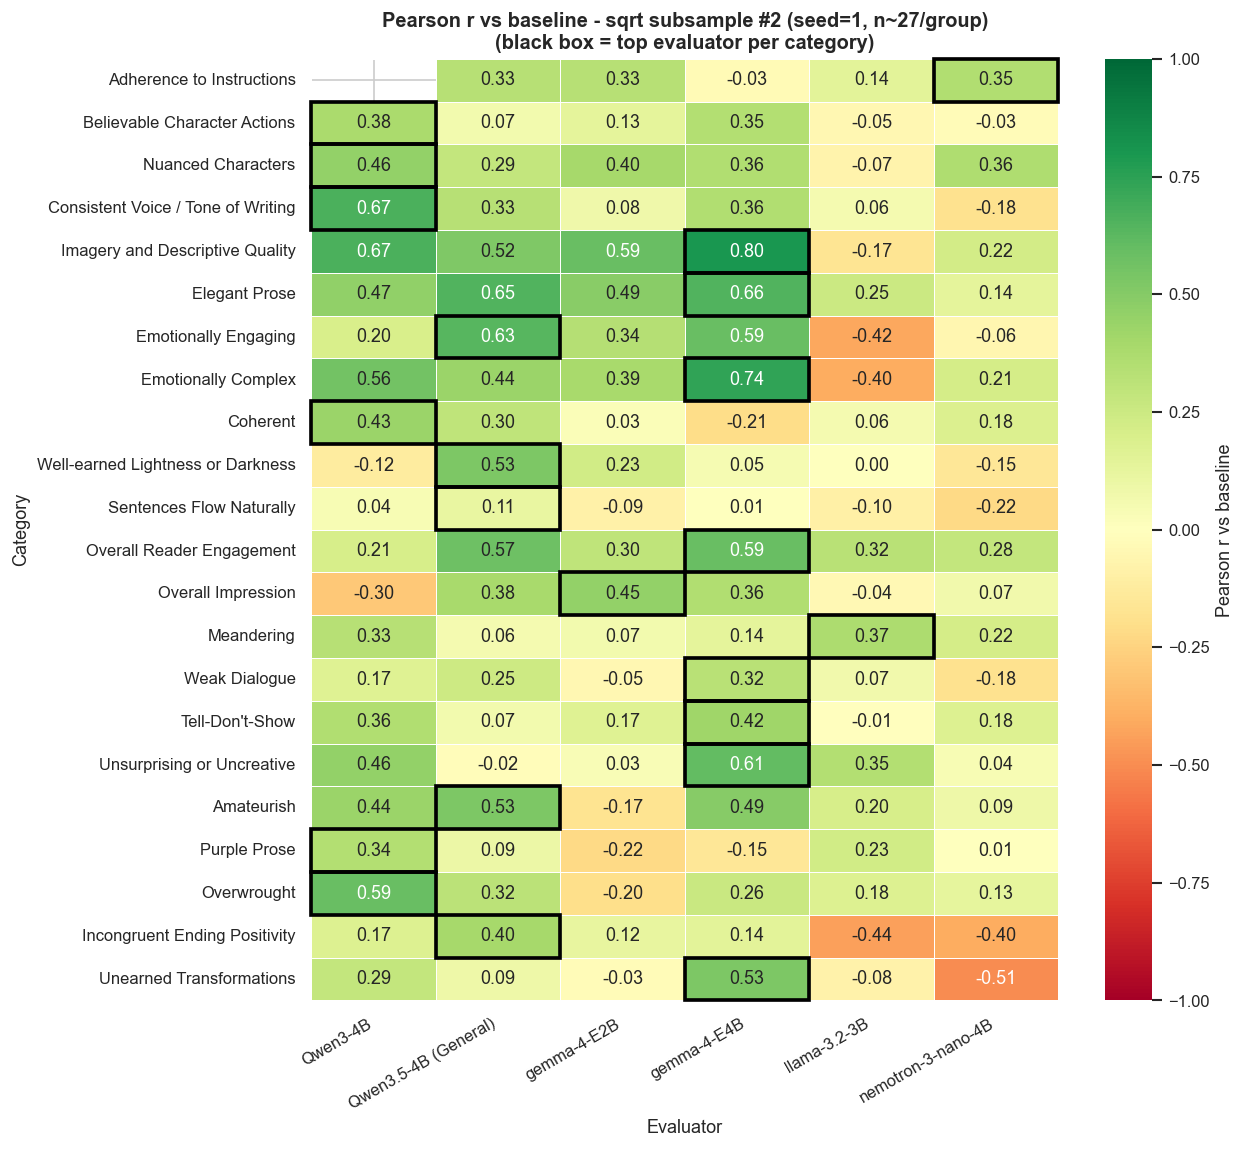

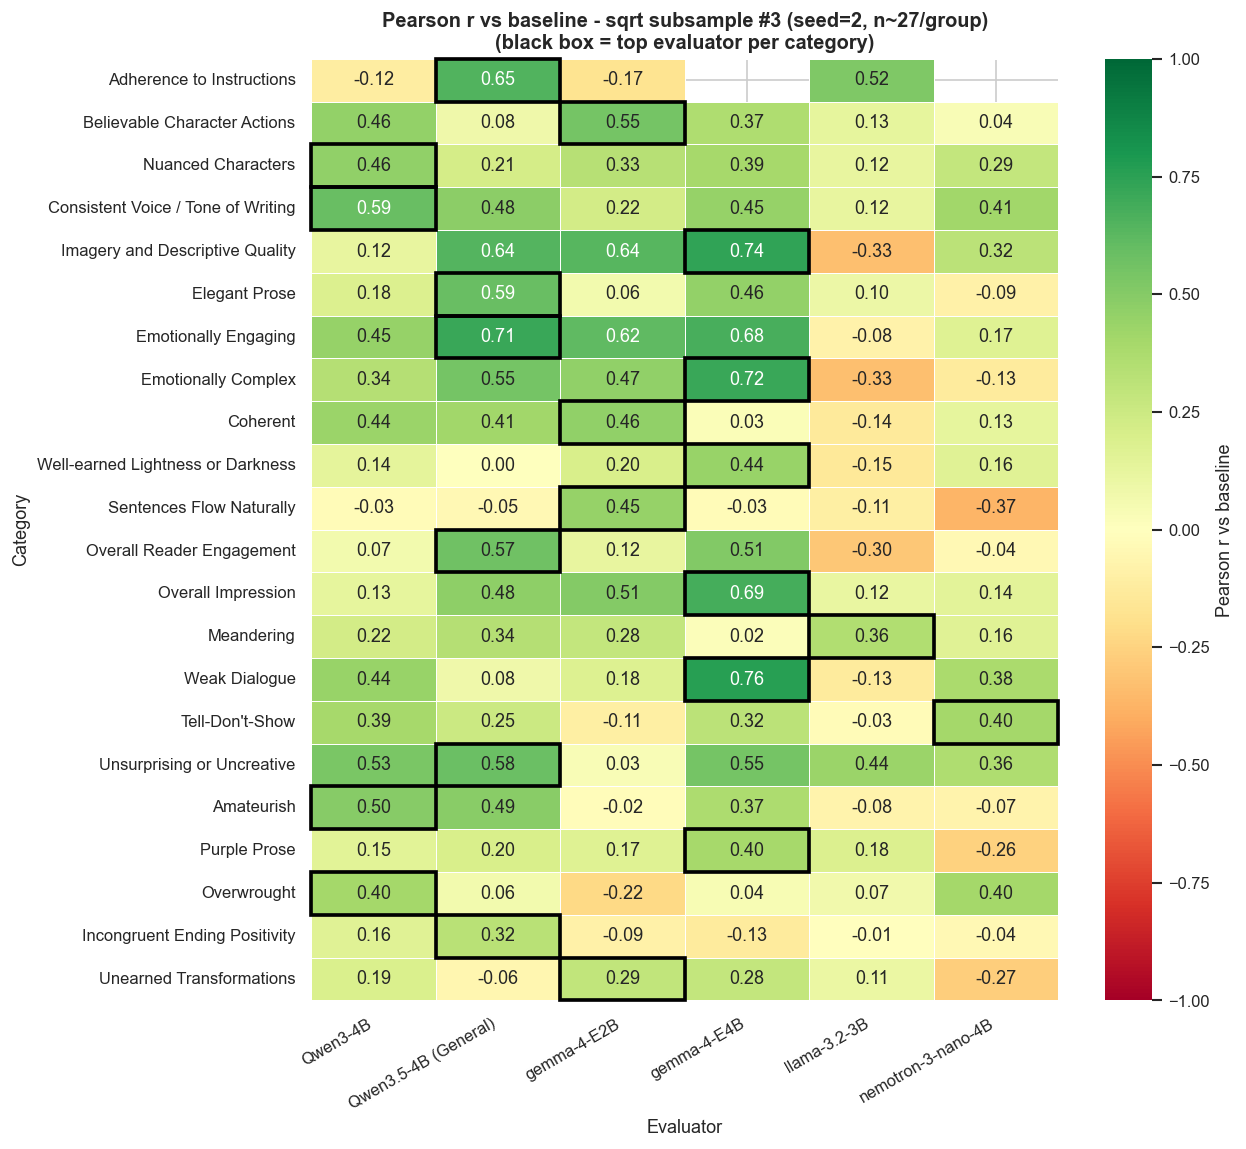

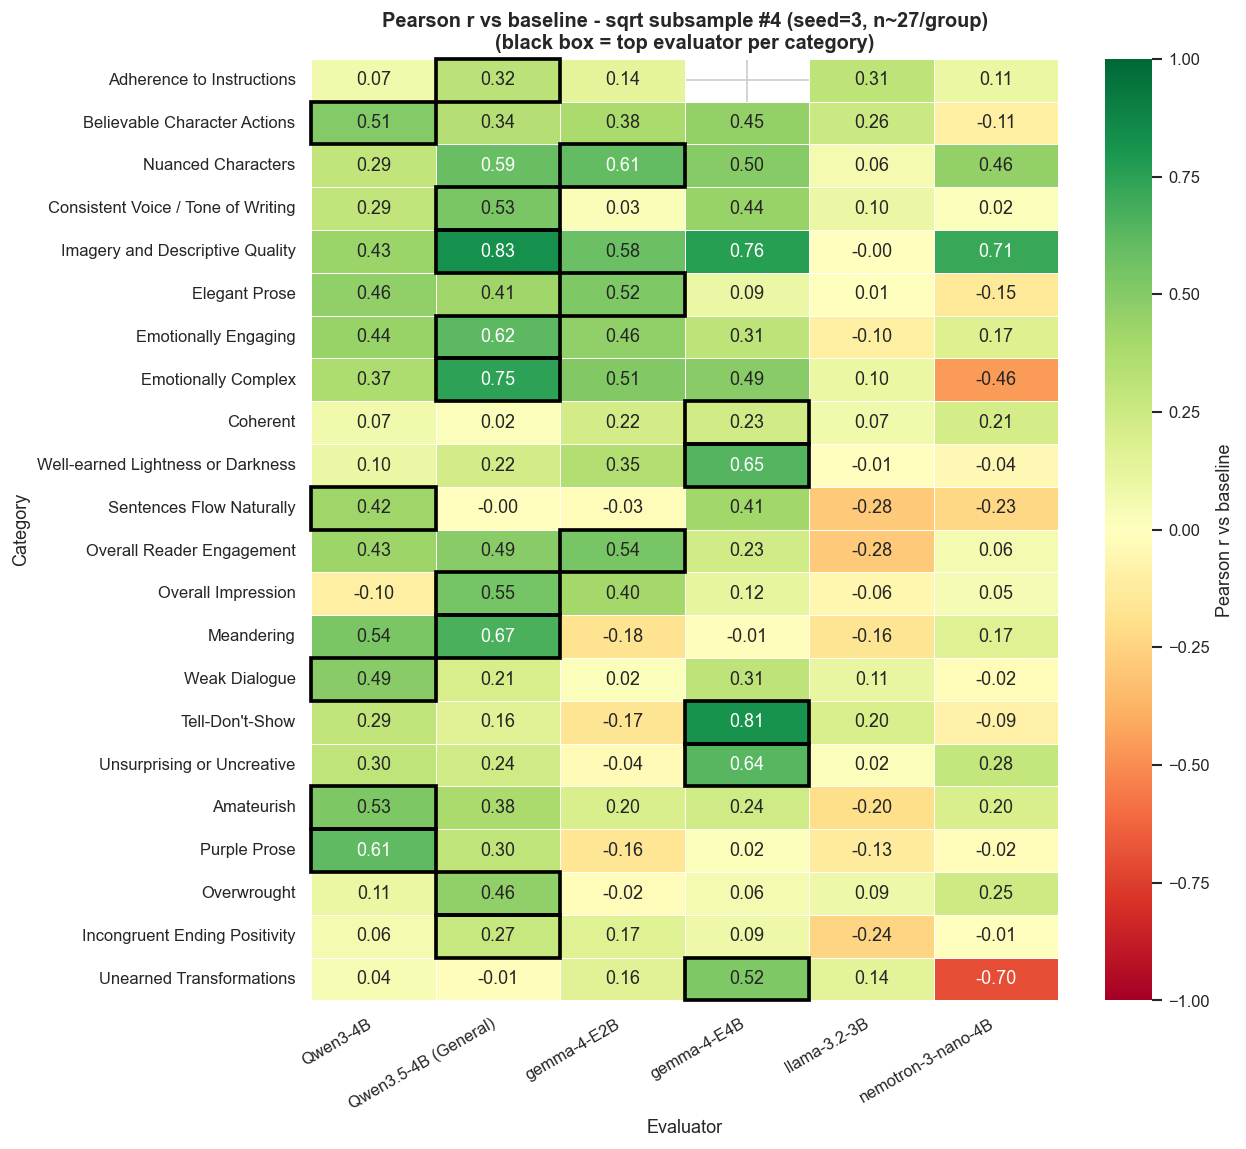

In [9]:
def sqrt_subsample(pairs_df, seed):
    rng = np.random.default_rng(seed)
    parts = []
    for _, g in pairs_df.groupby(["evaluator", "category"], sort=False):
        k = max(2, int(np.sqrt(len(g))))
        idx = rng.choice(len(g), size=min(k, len(g)), replace=False)
        parts.append(g.iloc[idx])
    return pd.concat(parts, ignore_index=True)


N_FIGURES = 4
for i in range(N_FIGURES):
    sample = sqrt_subsample(pairs, seed=i)
    n_per_group = int(np.sqrt(len(pairs) // (len(evaluator_names) * len(all_categories))))
    plot_agreement_heatmap(
        sample,
        title=(f"Pearson r vs baseline - sqrt subsample #{i + 1} "
               f"(seed={i}, n~{n_per_group}/group)"),
    )
    plt.tight_layout()
    plt.show()

## Mean-rank winner across subsamples

For each of $K$ subsamples and each category, rank evaluators 1..M by Pearson r (1 = best). Average ranks across all (subsample, category) pairs. Lower is better.

Overall mean rank (lower = better):
                      mean_rank  std_rank     n
evaluator                                      
Qwen3.5-4B (General)   2.430909  1.336731  1100
gemma-4-E4B            2.493409  1.408020  1062
Qwen3-4B               2.848089  1.462287  1073
gemma-4-E2B            3.645455  1.553337  1100
nemotron-3-nano-4B     4.538961  1.329567  1078
llama-3.2-3B           4.850909  1.333255  1100


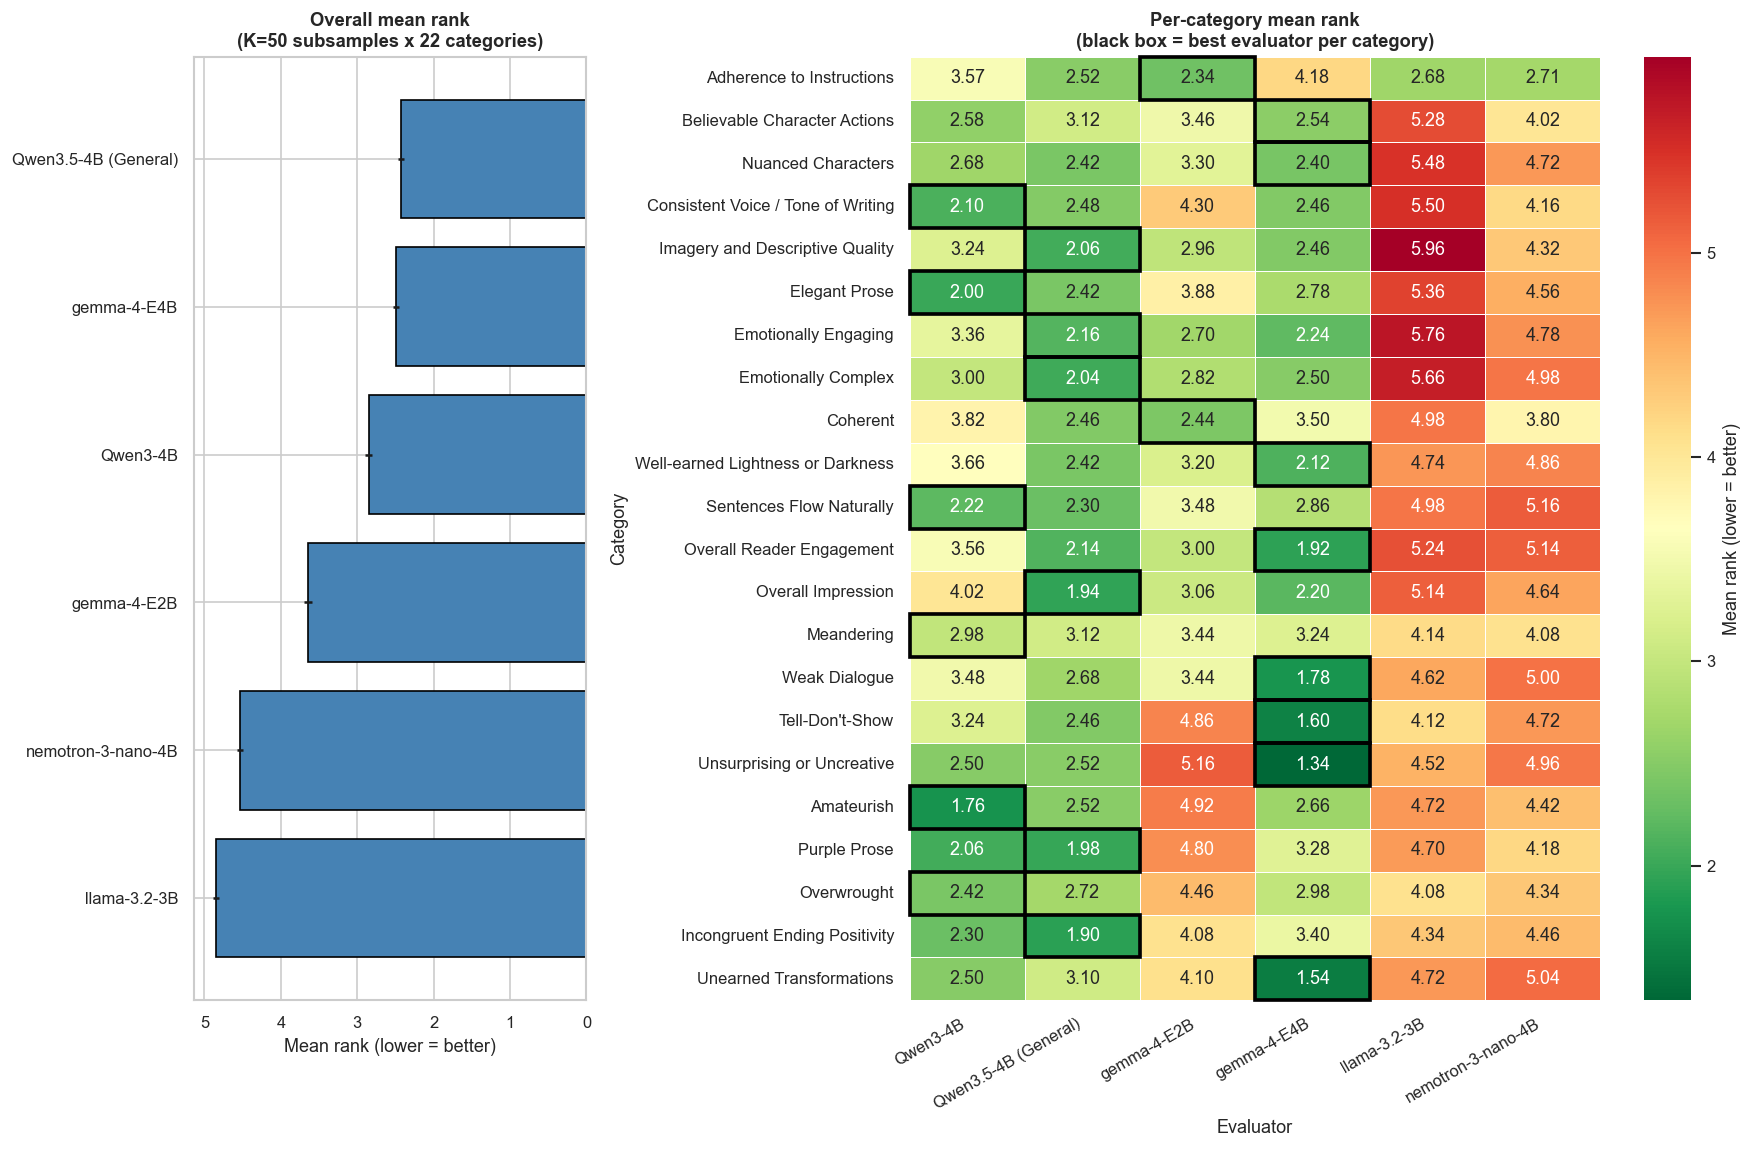

,mean_rank,std_rank,n
evaluator,,,
Qwen3.5-4B (General),2.430909,1.336731,1100
gemma-4-E4B,2.493409,1.408020,1062
Qwen3-4B,2.848089,1.462287,1073
gemma-4-E2B,3.645455,1.553337,1100
nemotron-3-nano-4B,4.538961,1.329567,1078
llama-3.2-3B,4.850909,1.333255,1100


In [10]:
K_SUBSAMPLES = 50

rank_frames = []
for seed in range(K_SUBSAMPLES):
    sample = sqrt_subsample(pairs, seed=seed)
    agree = compute_agreement(sample)
    pivot = agree.pivot_table(index="category", columns="evaluator", values="pearson_r")
    ranks = pivot.rank(axis=1, method="average", ascending=False)
    ranks = ranks.assign(seed=seed).reset_index().melt(
        id_vars=["category", "seed"], var_name="evaluator", value_name="rank"
    )
    rank_frames.append(ranks)

ranks_long = pd.concat(rank_frames, ignore_index=True)

overall = (
    ranks_long.groupby("evaluator")["rank"]
    .agg(["mean", "std", "count"])
    .reindex(evaluator_names)
    .rename(columns={"mean": "mean_rank", "std": "std_rank", "count": "n"})
)
print("Overall mean rank (lower = better):")
print(overall.sort_values("mean_rank"))

per_cat = (
    ranks_long.groupby(["category", "evaluator"])["rank"].mean()
    .unstack("evaluator")
    .reindex(index=POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES, columns=evaluator_names)
)

fig, (ax_bar, ax_heat) = plt.subplots(
    1, 2, figsize=(1.0 * len(evaluator_names) + 9, 0.35 * len(per_cat) + 2),
    gridspec_kw={"width_ratios": [1, 2.2]},
)

bar_order = overall.sort_values("mean_rank", ascending=False)
ax_bar.barh(bar_order.index, bar_order["mean_rank"],
            xerr=bar_order["std_rank"] / np.sqrt(bar_order["n"]),
            color="steelblue", edgecolor="black")
ax_bar.set_xlabel("Mean rank (lower = better)")
ax_bar.set_title(f"Overall mean rank\n(K={K_SUBSAMPLES} subsamples x {len(per_cat)} categories)",
                 fontsize=11, fontweight="bold")
ax_bar.invert_xaxis()

sns.heatmap(per_cat, cmap="RdYlGn_r", annot=True, fmt=".2f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Mean rank (lower = better)"}, ax=ax_heat)

min_cols = per_cat.idxmin(axis=1)
for row_idx, cat in enumerate(per_cat.index):
    ev = min_cols.loc[cat]
    if pd.isna(ev):
        continue
    col_idx = per_cat.columns.get_loc(ev)
    ax_heat.add_patch(mpatches.Rectangle((col_idx, row_idx), 1, 1,
                                         fill=False, edgecolor="black",
                                         lw=2.2, clip_on=False))

ax_heat.set_title("Per-category mean rank\n(black box = best evaluator per category)",
                  fontsize=11, fontweight="bold")
ax_heat.set_xlabel("Evaluator")
ax_heat.set_ylabel("Category")
ax_heat.tick_params(axis="x", rotation=30)
ax_heat.tick_params(axis="y", rotation=0)
for label in ax_heat.get_xticklabels():
    label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

overall.sort_values("mean_rank")